In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Sampler
from torch.cuda.amp import autocast, GradScaler
import torchvision
import torchvision.transforms as transforms
from torchvision import models
import timm
import pydicom
import os
from PIL import Image
from torchsummary import summary
from torch.optim.lr_scheduler import _LRScheduler, CyclicLR, OneCycleLR

import random
import matplotlib.pyplot as plt # For data viz
import pandas as pd
import numpy as np
from sklearn import metrics
from sklearn import decomposition
from sklearn import manifold
import sys
from tqdm.notebook import trange, tqdm
import ipywidgets as widgets
import time
import lmdb
import pickle
from sklearn.metrics import roc_curve, auc
import albumentations as A
from albumentations.pytorch import ToTensorV2
from albumentations.augmentations.dropout import CoarseDropout



import utils
import treniranja

print('System Version:', sys.version)
print('PyTorch version', torch.__version__)
print('Torchvision version', torchvision.__version__)
print('Numpy version', np.__version__)
print('Pandas version', pd.__version__)

print("CUDA available:", torch.cuda.is_available())
print("CUDA device name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA device")


System Version: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
PyTorch version 2.6.0+cu118
Torchvision version 0.21.0+cpu
Numpy version 2.1.3
Pandas version 2.2.3
System Version: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
PyTorch version 2.6.0+cu118
Torchvision version 0.21.0+cpu
Numpy version 2.1.3
Pandas version 2.2.3
System Version: 3.12.2 (tags/v3.12.2:6abddd9, Feb  6 2024, 21:26:36) [MSC v.1937 64 bit (AMD64)]
PyTorch version 2.6.0+cu118
Torchvision version 0.21.0+cpu
Numpy version 2.1.3
Pandas version 2.2.3
CUDA available: True
CUDA device name: NVIDIA GeForce GTX 1650


In [2]:
utils.seed_everything(42)

🔒 Seed set to: 42


In [3]:
def numpy_to_pil(x):
    return Image.fromarray(x.astype(np.uint8))

In [4]:
transform = transforms.Compose([
    transforms.Lambda(numpy_to_pil),    
    transforms.Resize((224,224), antialias=True),  # Resize using PIL (efficient)
    transforms.ToTensor(),  # Convert to tensor (H, W, C) → (C, H, W)
])

In [ ]:
# SAMO ZA PRVOTNU PRETVORBU PODATAKA
dicom_folder = "train/"                   # path to folder with .dcm files
labels_csv_path = "labels.csv"          # your CSV file
lmdb_output_path = "data/data.lmdb"     # output LMDB file
label_output_path = "labels.npy"        # output NumPy label file

# Generate LMDB and labels.npy
utils.LMDBsetup(dicom_folder, lmdb_output_path, labels_csv_path, label_output_path)


✅ Done. Saved 33126 resized images to data/data.lmdb


In [5]:
train_mapper, val_mapper, test_mapper, benign_percent  = utils.data_spliter("labels.npy",train_ratio=0.80, val_ratio=0.1, test_ratio=0.1)

In [6]:
image_size = 224    
train_transforms = A.Compose([
    A.Transpose(p=0.5),
    A.VerticalFlip(p=0.5),
    A.HorizontalFlip(p=0.5),
    A.OneOf([
        A.MotionBlur(blur_limit=5),
        A.MedianBlur(blur_limit=5),
        A.GaussianBlur(blur_limit=5),
        A.GaussNoise(var_limit=(5.0, 30.0)),
    ], p=0.7),
    A.OneOf([
        A.OpticalDistortion(distort_limit=1.0),
        A.GridDistortion(num_steps=5, distort_limit=1.),
        A.ElasticTransform(alpha=3),
    ], p=0.7),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=0.5),
    A.CLAHE(clip_limit=4.0, p=0.7),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, border_mode=0, p=0.85),
    A.Resize(image_size,image_size),
    A.CoarseDropout(
        max_holes=1,
        min_holes=1,
        max_height=int(image_size * 0.375),
        min_height=int(image_size * 0.375),
        max_width=int(image_size * 0.375),
        min_width=int(image_size * 0.375),
        fill_value=0,
        mask_fill_value=None,p=0.7),
    A.Normalize(),
    ToTensorV2()

])


test_transforms = A.Compose([
    A.Resize(image_size,image_size),
    A.Normalize(),
    ToTensorV2()
])


C:\Users\User\AppData\Local\Temp\ipykernel_13396\3780326857.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 30.0)),
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\albumentations\core\validation.py:87: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
C:\Users\User\AppData\Local\Temp\ipykernel_13396\3780326857.py:21: UserWarning: Argument(s) 'max_holes, min_holes, max_height, min_height, max_width, min_width, fill_value, mask_fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [17]:
# kako imamo puno vise primjera koji su benign nego malignant onda je ovo neka procedura kojom se to balansira
# ako je omjer benign:malignant a:b stavit cemo da samplea malignant a/(2b) puta vise nego benign
# i stavit cemo da kod racunanja loss function uzme da je pogreska kod malignanta a/(2b) puta veca
train_benign_count = int(len(train_mapper) * benign_percent)
train_malignant_count = len(train_mapper) - train_benign_count

# 0 = benign, 1 = malignant
label_sampler = torch.tensor(
    [0] * train_benign_count + [1] * train_malignant_count,
    dtype=torch.int64
)

# Step 2: Compute class counts
class_counts = torch.bincount(label_sampler) 
benign_count = class_counts[0].item()
malignant_count = class_counts[1].item()

ratio = benign_count / malignant_count

sample_class_weights = torch.tensor([1.0, ratio/2.0 ]) ######################################## kad cemo koristiti sampler staviti ratio/2.0
sample_weights = sample_class_weights[label_sampler]



# Step 5: Set loss function weights (for CrossEntropyLoss)
# We'll penalize mistakes on malignant a/(2b) times more
loss_class_weights = torch.tensor([1.0, ratio / 2.0], dtype=torch.float32) ######################################## kad cemo koristiti sampler staviti ratio/2.0

In [21]:

import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.RandomResizedCrop(size=(384, 384), scale=(0.8, 1.0), ratio=(0.75, 1.33)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.Normalize(),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=384, width=384),
    A.Normalize(),
    ToTensorV2()
])


# Dataset creation
train_dataset = utils.LMDBImageDataset("data/data.lmdb", "labels.npy", train_mapper, transform=train_transforms)
val_dataset = utils.LMDBImageDataset("data/data.lmdb", "labels.npy", val_mapper,transform=test_transforms)

'''test_dataset = utils.LMDBImageDataset(
    lmdb_path=train_lmdb_path,
    label_path=label_path,
    data_mapper=test_idx,
    transform=val_transform
)'''

batch_size = 8

test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


Dataset initialized. Total length: 26500
Dataset initialized. Total length: 3312


In [22]:
train_dataset_jpg = utils.LMDBImageDataset("data/data_jpg.lmdb", "labels.npy", train_mapper, transform=train_transforms)
val_dataset_jpg = utils.LMDBImageDataset("data/data_jpg.lmdb", "labels.npy", val_mapper,transform=test_transforms)

batch_size = 8

#sampler = utils.OversampleMinoritySampler(train_dataset, oversample_factor = 25)

train_loader_jpg = DataLoader(train_dataset, batch_size=batch_size,sampler = sampler)
test_loader_jpg = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Error: data/data_jpg.lmdb: The system cannot find the path specified.


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Small_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Stopping early, the loss has diverged


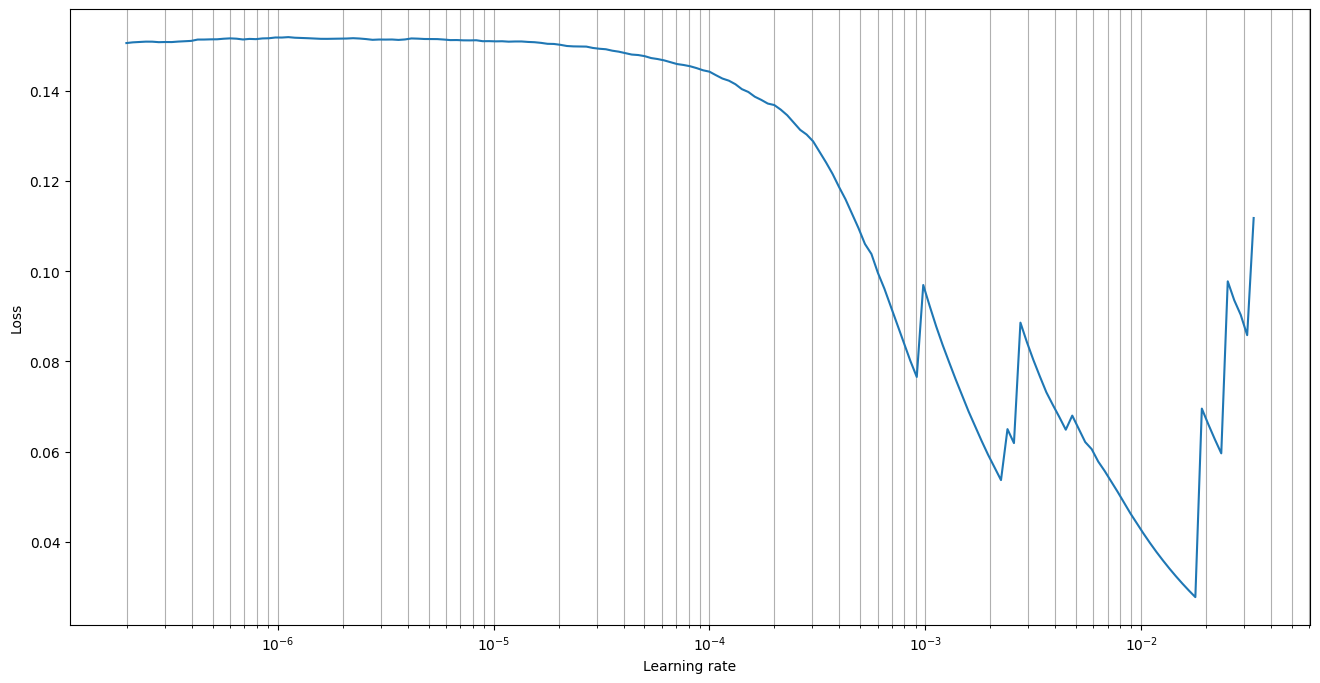

In [ ]:
# ovo služi za traženje optimalnog lr ako se samo koristi lr onda 
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model = treniranja.ConvNeXtBinaryClassifier(dropout=0.5).to(device)
treniranja.freeze_backbone(model)

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': 1e-5},    # tu koristim optimizer koji ima različit lr za head i backbone
    {'params': model.head.parameters(), 'lr':1e-7}],        # backbone je ConvNeXtBinaryClassifier u ovom slučaju a head su kao fc layeri koje dodam na to
    weight_decay = 0.01                
    )

criterion = utils.FocalLoss(alpha=0.85, gamma=2.0)


utils.lr_finder(model ,test_loader, optimizer, criterion=criterion, just_head =1,NUM_ITER=1000)

Prob range: [0.50055766] [0.5078951]
Pred class 1 count: 3312
True class 1 count: 58


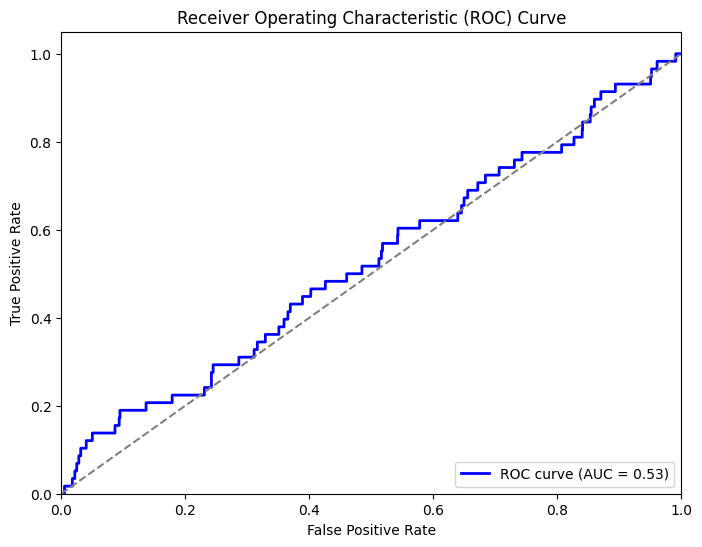

In [24]:
torch.save(model.state_dict(), "convnext_small_sampler_50.pth") 
utils.probabilities_range(model, test_loader)
tpr, fpr,auc = utils.draw_roc(model, test_loader)